<a href="https://colab.research.google.com/github/EricoCoutoJr/Superstore-Dataset/blob/main/Superstore_Data_Analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Superstore Data Analysis**

---

### **Proposta de análise de dados do dataset importado do Kaggle**
#### **Conjunto de dados contendo vendas e lucros de uma loja (Superstore)**


---

Algumas perguntas devem ser feitas aos dados.
- Existe diferensa de faturamento entre os dias da semana?
- Qual tipo de envio gera mais receita?
- Como ocorre a distribuição de faturamento pelas regiões?
- Como estão se comportando as margens de lucro?

---



#### Iniciando o processo de localização do arquivo a ser tratado.

In [ ]:
# Install dependencia se necessário:
# pip install kagglehub[pandas-datasets]

# Carregando biblioteca
import kagglehub

# Preparando o caminho para acessar do dataset diretamente do Keggle
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


Importação do dataset da origem para um dataframe

In [ ]:
# Carregando bibliotecas
# que serão usadas na análise e manipulação do dataset
import numpy as np
import pandas as pd


# Carregando versão atualizada do dataset diretamente do Keggle
df = pd.read_csv(path + "/Sample - Superstore.csv", encoding="latin-1")

# Apresentação das primeiras linhas do dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Iniciando o processo de entendimento das dimenções do dataset**

Metadados

* ID da linha => ID exclusivo para cada linha
* ID do pedido => ID do pedido exclusivo para cada cliente
* Data do pedido => Data do pedido do produto
* Data de Envio => Data de Envio do Produto
* Modo de Envio=> Modo de Envio especificado pelo Cliente
* ID do Cliente => ID exclusivo para identificar cada Cliente
* Nome do Cliente => Nome do Cliente
* Segmento => O segmento ao qual o Cliente pertence
* País => País de residência do Cliente
* Cidade => Cidade de residência do Cliente
* Estado => Estado de residência do Cliente
* Código Postal => Código Postal de cada Cliente
* Região => Região a que pertence o Cliente
* ID do produto => ID exclusivo do produto
* Categoria => Categoria do produto encomendado
* Subcategoria => Subcategoria do produto encomendado
* Nome do Produto => Nome do Produto
* Vendas => Vendas do Produto
* Quantidade => Quantidade do Produto
* Desconto => Desconto fornecido
* Lucro => Lucro/Perda incorrido

Na celula abaixo serão listadas as variáveis e seus tipos (metadados) do dataset.

In [ ]:
print("Dados dimensionais do dataset: \n")
df.info()

Dados dimensionais do dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994

Na celula a seguir é apresentado alguns dados estatísticos das variáveis numéricas.

In [ ]:
print("Dados estatísticos do dataset: \n")
df.describe()

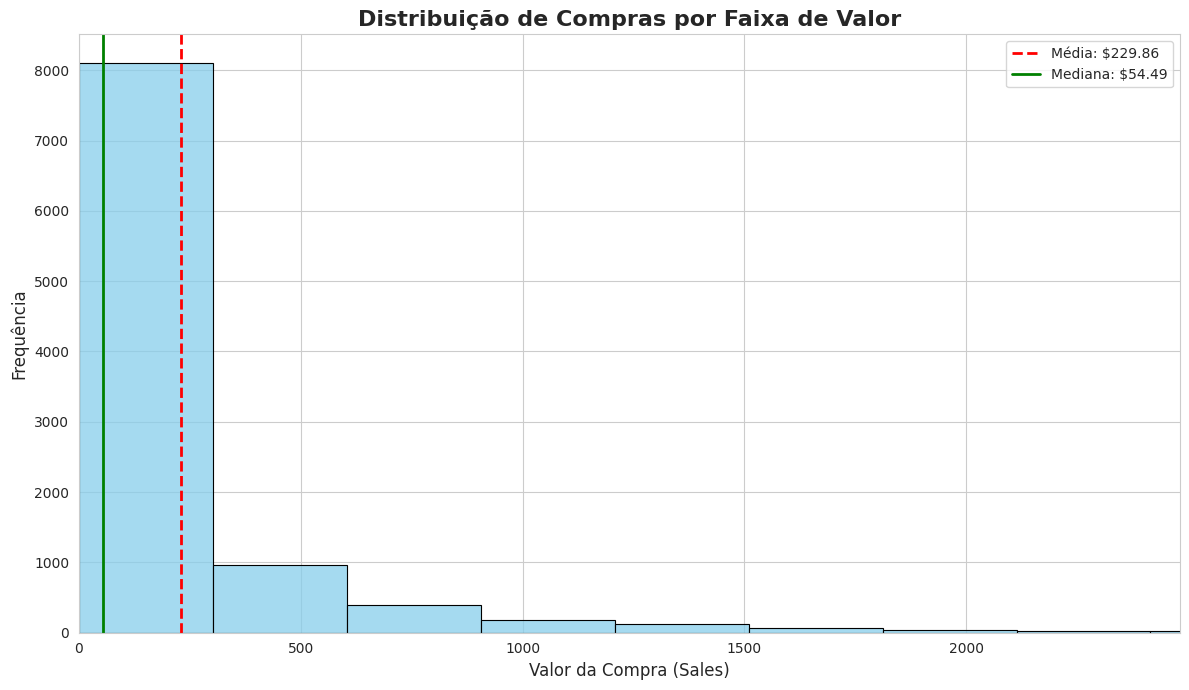

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas
media_sales = df['Sales'].mean()
mediana_sales = df['Sales'].median()

# Configuração visual
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Histograma
sns.histplot(
    data=df,
    x='Sales',
    bins=75,              # ajuste conforme granularidade desejada
    kde=False,
    color='skyblue',
    edgecolor='black'
)

# Linha da média
plt.axvline(
    media_sales,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Média: ${media_sales:,.2f}'
)

# Linha da mediana
plt.axvline(
    mediana_sales,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f'Mediana: ${mediana_sales:,.2f}'
)

# Títulos e labels
plt.title('Distribuição de Compras por Faixa de Valor', fontsize=16, fontweight='bold')
plt.xlabel('Valor da Compra (Sales)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Melhorar visualização (dados de vendas costumam ter cauda longa)
plt.xlim(0, df['Sales'].quantile(0.99))  # corta outliers extremos para visualização

plt.legend()
plt.tight_layout()
plt.show()

**Tratando dados nulos**

Abaixo vamos identidicar eventuais dados nulos. Obviamente essa informação já foi verificada quando foi aplicado a função info() no dataframe.

In [ ]:
df.isnull().sum()

**Cuidado:** muitos datasets parecem limpos, mas têm “nulos disfarçados”, por exemplo:

* string vazia ''
* espaço ' '
* "NA"
* "Null"
* "None"
* "?"

Para tentar identificar qualquer um destes será utilizado o código abaixo

In [ ]:
df.isin(['', ' ', 'NA', 'Null', 'None', '?']).sum()

Como não tenha sido identificado registro com dados nulos seguiremos para o passo seguinte. Caso tenha encontrado algum NULO ou vazio, podemos eliminar a linha ou coluna, ou até inserir um dados (como por exemplo: média, mediana ou moda)


---



Removendo registros duplicados se houver.

In [ ]:

# Verificar quantidade de duplicados
duplicados = df.duplicated()

print(f'Total de registros duplicados: {duplicados.sum()}')

# Visualizar registros duplicados
df_duplicados = df[df.duplicated(keep=False)]  # mostra todos os envolvidos

print('\nRegistros duplicados encontrados:')
print(df_duplicados.sort_values(by='Order ID').head(10))

# Remover duplicados
df_limpo = df.drop_duplicates()

print(f'\nAntes da remoção: {df.shape[0]} linhas')
print(f'Depois da remoção: {df_limpo.shape[0]} linhas')

# Confirmar limpeza
print(f'Duplicados restantes: {df_limpo.duplicated().sum()}')

Total de registros duplicados: 0

Registros duplicados encontrados:
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]

Antes da remoção: 9994 linhas
Depois da remoção: 9994 linhas
Duplicados restantes: 0


**OBS.: Não foram encontrados registros DUPLICADOS**

## **Tratando datas para poder fazer operações com datas (datetime).**


Criando variáveis de dias para envio, dia da semana da compra, mês, ano, trimestre, mês (numerico) da compra, trimestre e semana do ano da compra.

Isso posbilitará uma grande quantidade de análises temporais e de forma segmentada.

---



In [ ]:
# Converter datas para DateTime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Criando novas variáveis com data

# Criar dias para envio
df["Dias_Envio"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Dia da semana em inglês
df["Dia_Semana"] = df["Order Date"].dt.day_name()

# Nome do mês em inglês
df["Mes"] = df["Order Date"].dt.month_name()

# Número do mês
df["Mes_Num"] = df["Order Date"].dt.month

# Ano
df["Ano"] = df["Order Date"].dt.year

# Trimestre
df["Trimestre"] = df["Order Date"].dt.quarter

# Semana do ano
df["Semana_Ano"] = df["Order Date"].dt.isocalendar().week


# Tradução para Português os Dias de Semana e Meses

dias_pt = {
    "Monday": "Segunda",
    "Tuesday": "Terça",
    "Wednesday": "Quarta",
    "Thursday": "Quinta",
    "Friday": "Sexta",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

meses_pt = {
    "January": "Janeiro",
    "February": "Fevereiro",
    "March": "Março",
    "April": "Abril",
    "May": "Maio",
    "June": "Junho",
    "July": "Julho",
    "August": "Agosto",
    "September": "Setembro",
    "October": "Outubro",
    "November": "Novembro",
    "December": "Dezembro"
}

# Aplicar tradução
df["Dia_Semana"] = df["Dia_Semana"].map(dias_pt)
df["Mes"] = df["Mes"].map(meses_pt)

# Visualizar resultado
df.head()


df.head()

Continuando a limpeza de dados desnecessários para o trabalho de análise dos dados.

Uma **Análise Exploratória de Dados (AED)** no dataset **Superstore**, algumas colunas costumam ter baixo valor analítico ou serem redundantes/identificadores puros. Algumas colunas que podem ser removidas e porquê.

Por quê:

- Row ID → apenas índice artificial, sem valor analítico.
- Order ID → identificador transacional; útil só para contar pedidos únicos.
- Customer ID → identificador; pouco útil em AED geral.
- Customer Name → dado nominal, pouco agregável e menos relevante.
- Product ID → identificador técnico.

In [ ]:
colunas_remover = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID"
]

df_clean = df.drop(columns=colunas_remover)

df_clean.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,...,Quantity,Discount,Profit,Dias_Envio,Dia_Semana,Mes,Mes_Num,Ano,Trimestre,Semana_Ano
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,2,0.00,41.9136,3,Terça,Novembro,11,2016,4,45
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,3,0.00,219.5820,3,Terça,Novembro,11,2016,4,45
2,2016-06-12,2016-06-16,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,2,0.00,6.8714,4,Domingo,Junho,6,2016,2,23
3,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,5,0.45,-383.0310,7,Domingo,Outubro,10,2015,4,41
4,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,2,0.20,2.5164,7,Domingo,Outubro,10,2015,4,41


Manteremos o dataset Original, apenas com o tratamento das datas (datetime) e sem dados nulos

- **df →** com tratamento de data e limpeza de dados nulos
- **df_clean →** dataset com tratamento de datas, limpeza de nulos e remoção de colunas (variáveis) com baixo valor analítico.

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Dias_Envio,Dia_Semana,Mes,Mes_Num,Ano,Trimestre,Semana_Ano
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,3,Terça,Novembro,11,2016,4,45
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,3,Terça,Novembro,11,2016,4,45
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,4,Domingo,Junho,6,2016,2,23
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7,Domingo,Outubro,10,2015,4,41
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,7,Domingo,Outubro,10,2015,4,41


# **Fazendo análises preliminares**


---

Vamos iniciar entendendo as compras por dia da semana

In [ ]:
# Listando a totalização de vendas por tipo de envio a saida foi formatada para melhor visualização dos valores
ship_by_weekday = df.groupby("Dia_Semana")["Sales"].sum().sort_values(ascending=False)
ship_by_weekday_formatado = ship_by_weekday.apply(lambda x: f'US$ {x:,.2f}')
print(ship_by_weekday_formatado.head(10))

Dia_Semana
Segunda    US$ 428,937.82
Sexta      US$ 427,692.26
Domingo    US$ 385,353.85
Sábado     US$ 357,984.68
Quinta     US$ 321,965.78
Terça      US$ 287,209.50
Quarta      US$ 88,056.98
Name: Sales, dtype: object


Foi observado uma concentração de compras no fim de semana incluindo a segunda-feira. **Com um destaque para quarta-feira, quando as vendas são muito baixa.**

A seguir uma breve apresentação vedas, lucro, quantidades e desconto por categoria.

In [ ]:
total_por_categoria=df.groupby("Category").agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum",
    "Discount":"mean"
})

total_por_categoria.head()

,Sales,Profit,Quantity,Discount
Category,,,,
Furniture,741999.7953,18451.2728,8028,0.173923
Office Supplies,719047.0320,122490.8008,22906,0.157285
Technology,836154.0330,145454.9481,6939,0.132323


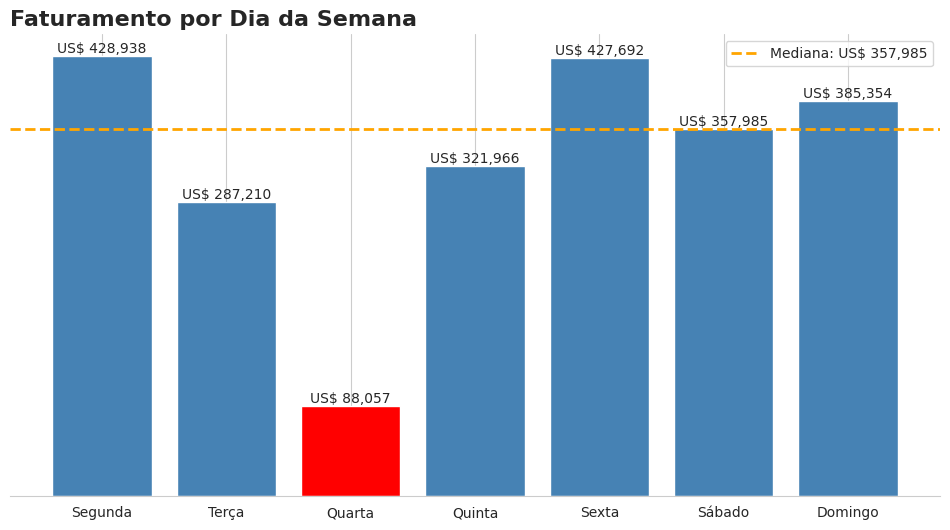

In [ ]:
# Ordem correta dos dias
ordem_dias = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo"
]

# Agrupamento
ship_by_weekday = (
    df_clean.groupby("Dia_Semana")["Sales"]
    .sum()
    .reindex(ordem_dias)
)

# Identificar menor valor
menor_dia = ship_by_weekday.idxmin()

# Calcular mediana
mediana = ship_by_weekday.median()

# Criar cores
cores = [
    "red" if dia == menor_dia else "steelblue"
    for dia in ship_by_weekday.index
]

# Criar gráfico
plt.figure(figsize=(12,6))

bars = plt.bar(
    ship_by_weekday.index,
    ship_by_weekday.values,
    color=cores
)

# Inserir linha da mediana
plt.axhline(
    y=mediana,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: US$ {mediana:,.0f}'
)

# Adicionar valores nas barras
for bar in bars:

    valor = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        valor,
        f'US$ {valor:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Título
plt.title(
    "Faturamento por Dia da Semana",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

# Legenda
plt.legend()

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Retirando os Contorno
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Retirando a escala vertical
plt.yticks([])

plt.show()

Na célula a baixa é listado os totais de vendas por tipo de envio.

In [ ]:
# Listando a totalização de vendas por tipo de envio a saida foi formatada para melhor visualização dos valores
ship_mode = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)
ship_mode_formatado = ship_mode.apply(lambda x: f'US$ {x:,.2f}')
print(ship_mode_formatado.head(10))

Ship Mode
Standard Class    US$ 1,358,215.74
Second Class        US$ 459,193.57
First Class         US$ 351,428.42
Same Day            US$ 128,363.12
Name: Sales, dtype: object


Vamos analisar o compoprtamento das **vendas por modo de envio**.

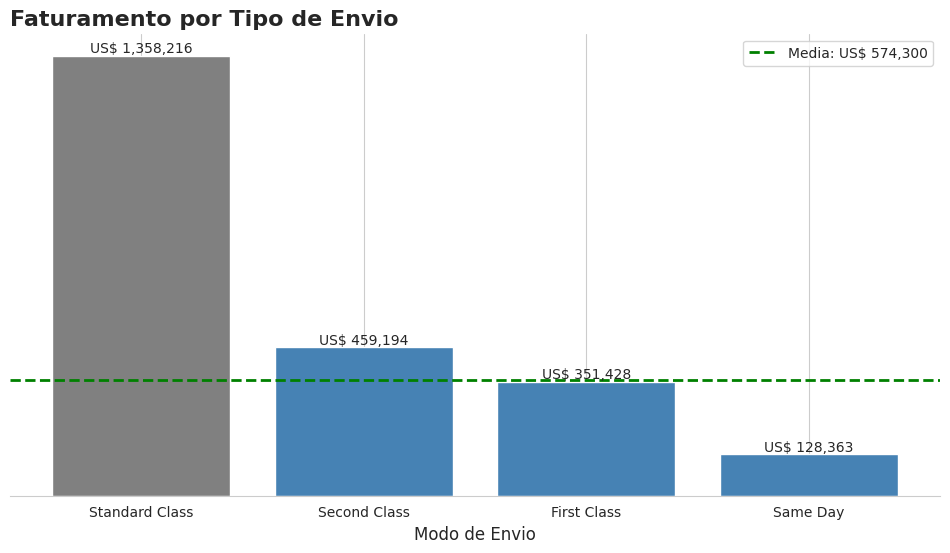

In [ ]:
# Agrupamento das vendas por modo de envio
ship_mode = (
    df_clean.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Identificar maior faturamento
maior = ship_mode.idxmax()

# Calcular mediana
media = ship_mode.mean()

# Definir cores
cores = []

for modo in ship_mode.index:

    if modo == maior:
        cores.append("gray")      # menor faturamento
    else:
        cores.append("steelblue")

# Criar gráfico
plt.figure(figsize=(12,6))

bars = plt.bar(
    ship_mode.index,
    ship_mode.values,
    color=cores
)

# Inserir linha da mediana
plt.axhline(
    y=mediana,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Media: US$ {media:,.0f}'
)

# Inserir valores nas barras
for bar in bars:

    valor = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        valor,
        f'US$ {valor:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Título
plt.title(
    "Faturamento por Tipo de Envio",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

# Labels
plt.xlabel("Modo de Envio", fontsize=12)

# Grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Legenda
plt.legend()

# Retirando os Contorno
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Retirando a escala vertical
plt.yticks([])

# Exibir gráfico
plt.show()

O Tiket médio por venda é fornecido pelo código abaixo.

In [ ]:
sum_sales=df.groupby("Order ID")["Sales"].sum()
sum_sales.mean()

np.float64(458.61466566180883)

Agora podemos analisar o compoprtamento das **vendas por regiões** geográficas.

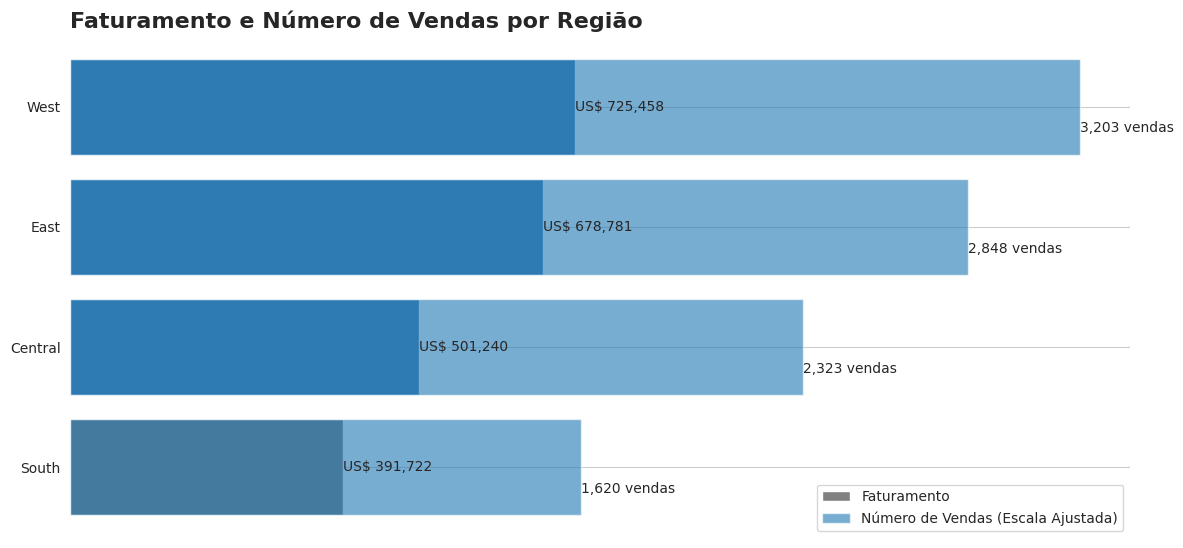

In [ ]:
import numpy as np

# Agrupamento por região
region_analysis = (
    df_clean.groupby("Region")
    .agg({
        "Sales": "sum",
        "Order Date": "count"
    })
    .rename(columns={"Order Date": "Qtd_Vendas"})
    .sort_values(by="Sales", ascending=True)
)

# Dados
regioes = region_analysis.index
sales = region_analysis["Sales"]
qtd_vendas = region_analysis["Qtd_Vendas"]

# NORMALIZAÇÃO
# Escalar quantidade de vendas para melhorar visualização
qtd_vendas_scaled = (
    qtd_vendas*2 / qtd_vendas.max()
) * sales.max()

# FIGURA
plt.figure(figsize=(12,6))

# Barra de faturamento (fundo)
plt.barh(
    regioes,
    sales,
    color=cores,
    alpha=1,
    label="Faturamento"
)

# Barra de quantidade de vendas (sobreposta)
plt.barh(
    regioes,
    qtd_vendas_scaled,
    alpha=0.6,
    label="Número de Vendas (Escala Ajustada)"
)

# LABELS FATURAMENTO
for i, valor in enumerate(sales):

    plt.text(
        valor,
        i,
        f'US$ {valor:,.0f}',
        va='center',
        fontsize=10
    )

# LABELS QUANTIDADE
for i, valor in enumerate(qtd_vendas):

    plt.text(
        qtd_vendas_scaled.iloc[i],
        i - 0.18,
        f'{valor:,} vendas',
        va='center',
        fontsize=10
    )

# TÍTULO
plt.title(
    "Faturamento e Número de Vendas por Região",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

# LEGENDA
plt.legend()

# REMOVER CONTORNOS
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# LAYOUT
plt.tight_layout()

# Retirando escala horizontal
plt.xticks([])

plt.show()

A seguir é apresentado o gráfico de **faturamento e o lucro por categoria de produto.**

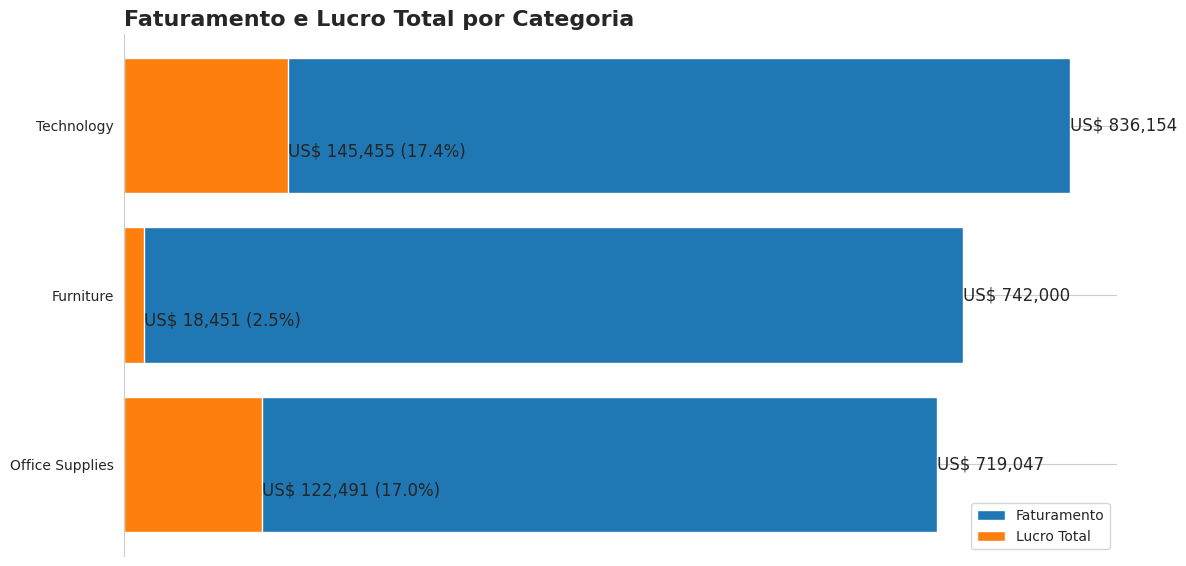

In [ ]:
# Agrupamento por categoria
category_analysis = (
    df_clean.groupby("Category")
    .agg({
        "Sales": "sum",
        "Profit": "sum"
    })
    .sort_values(by="Sales", ascending=True)
)

# Dados
categorias = category_analysis.index
sales = category_analysis["Sales"]
profit = category_analysis["Profit"]

# Criar figura
plt.figure(figsize=(12,6))

# Barra de faturamento (fundo)
plt.barh(
    categorias,
    sales,
    label="Faturamento"
)

# Barra de lucro (sobreposta)
plt.barh(
    categorias,
    profit,
    label="Lucro Total"
)

# Inserir valores do faturamento
for i, valor in enumerate(sales):

    plt.text(
        valor,
        i,
        f'US$ {valor:,.0f}',
        va='center',
        fontsize=12
    )

# Inserir valores do lucro com percentual
for i, valor in enumerate(profit):

    percentual = (valor / sales.iloc[i]) * 100

    plt.text(
        valor,
        i - 0.15,
        f'US$ {valor:,.0f} ({percentual:.1f}%)',
        va='center',
        fontsize=12
    )

# Título
plt.title(
    "Faturamento e Lucro Total por Categoria",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Legenda
plt.legend()

# Removendo contornos
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Ajustar layout
plt.tight_layout()

# Retirando escala horizontal
plt.xticks([])

# Exibir gráfico
plt.show()

Agora vamos entender a distribuição dos lucros ou prejuízos em cada venda

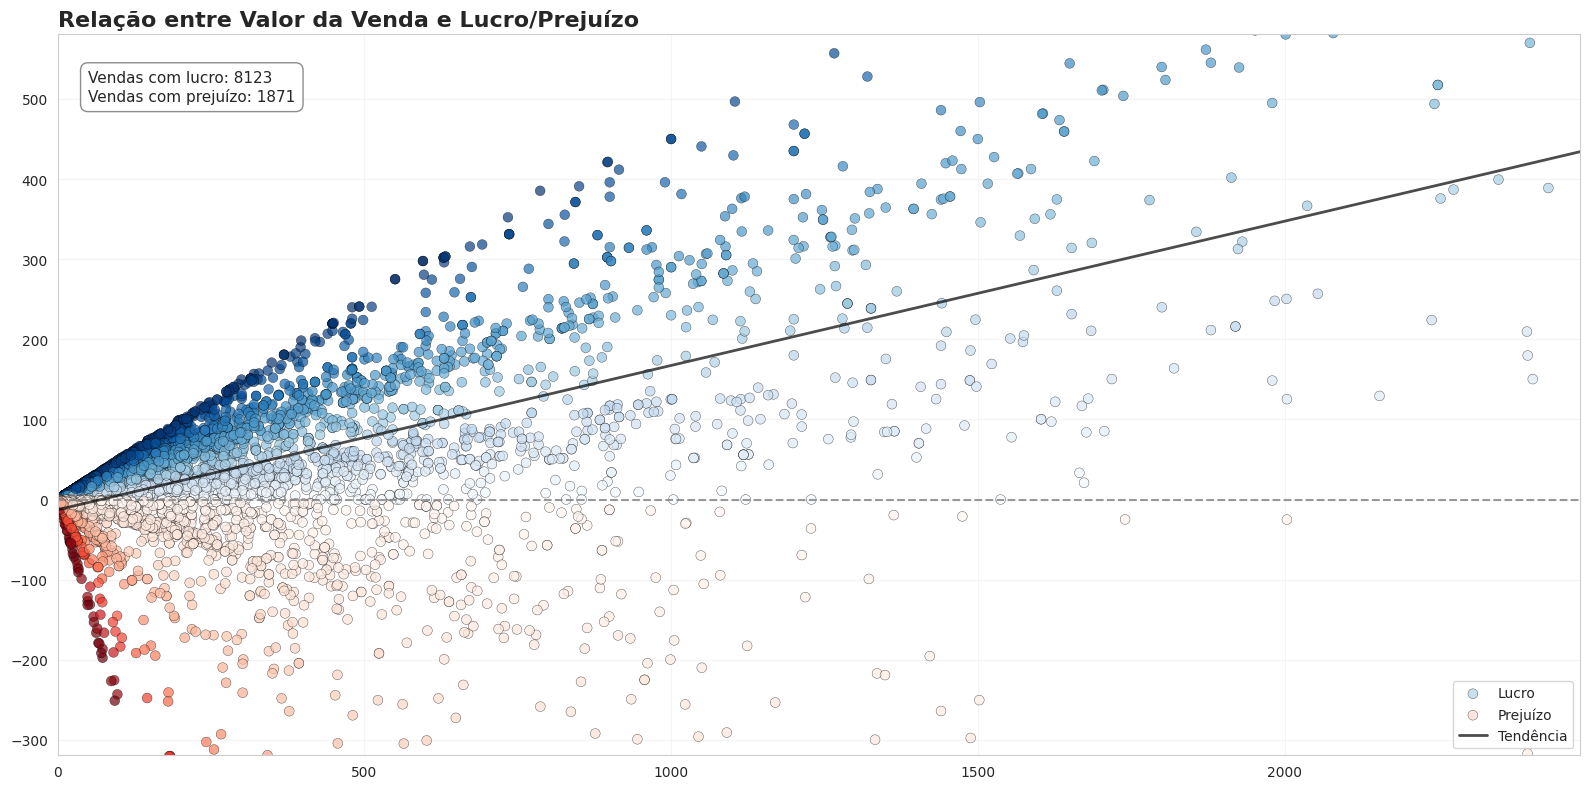

In [ ]:

# Criar percentual de lucro
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# Separar lucro e prejuízo
lucro = df[df['Profit'] >= 0].copy()
prejuizo = df[df['Profit'] < 0].copy()

# Contagens
qtd_lucro = len(lucro)
qtd_prejuizo = len(prejuizo)

# Normalização de cores
norm_lucro = plt.Normalize(
    lucro['Profit_Margin'].min(),
    lucro['Profit_Margin'].max()
)

norm_prejuizo = plt.Normalize(
    prejuizo['Profit_Margin'].min(),
    prejuizo['Profit_Margin'].max()
)

# Criar figura
plt.figure(figsize=(16, 8))

# Scatter lucro
scatter_lucro = plt.scatter(
    lucro['Sales'],
    lucro['Profit'],
    c=lucro['Profit_Margin'],
    cmap='Blues',
    norm=norm_lucro,
    alpha=0.7,
    s=50,
    edgecolors='black',
    linewidth=0.3,
    label='Lucro'
)

# Scatter prejuízo
scatter_prejuizo = plt.scatter(
    prejuizo['Sales'],
    prejuizo['Profit'],
    c=prejuizo['Profit_Margin'],
    cmap='Reds_r',
    norm=norm_prejuizo,
    alpha=0.7,
    s=50,
    edgecolors='black',
    linewidth=0.3,
    label='Prejuízo'
)

# Linha horizontal no zero
plt.axhline(
    y=0,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8
)

# Linha de tendência
z = np.polyfit(df['Sales'], df['Profit'], 1)
p = np.poly1d(z)

x_sorted = np.sort(df['Sales'])
plt.plot(
    x_sorted,
    p(x_sorted),
    color='black',
    linewidth=2,
    alpha=0.7,
    label='Tendência'
)

# Caixa informativa
texto_info = (
    f'Vendas com lucro: {qtd_lucro}\n'
    f'Vendas com prejuízo: {qtd_prejuizo}'
)

plt.text(
    0.02, 0.95,
    texto_info,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

# Limites para reduzir efeito de outliers
plt.xlim(0, df['Sales'].quantile(0.99))
plt.ylim(
    df['Profit'].quantile(0.01),
    df['Profit'].quantile(0.99)
)

# Títulos
plt.title(
    'Relação entre Valor da Venda e Lucro/Prejuízo',
    fontsize=16,
    fontweight='bold',
    loc='left'
)


plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Agora vamos salvar um arquivo CSV para servir de base para a construção de dashboards através do uso de outras ferramentas. Como exemplo podemos usar uma das seguintes ferramentas: Looker, Power BI, Qlik ou outras.

In [ ]:
# Salvar dataset tratado em CSV
df_clean.to_csv(
    "superstore_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo CSV salvo com sucesso!")

Arquivo CSV salvo com sucesso!
